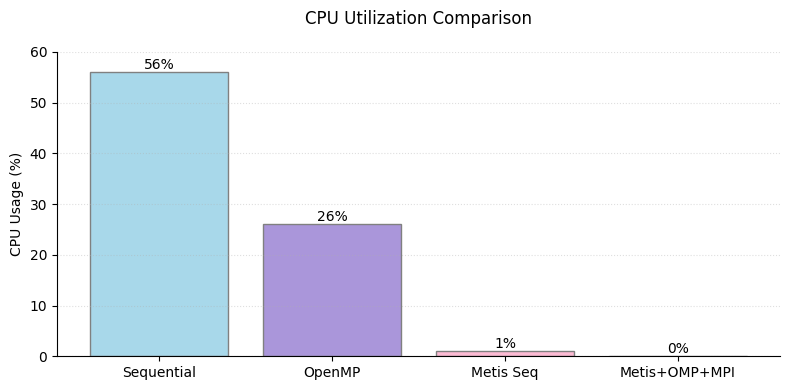

In [2]:
import matplotlib.pyplot as plt

# Data
features = ['Sequential', 'OpenMP', 'Metis Seq', 'Metis+OMP+MPI']
cpu_usage = [56, 26, 1, 0]
colors = ['#a8d8ea', '#aa96da', '#fcbad3', '#ffffd2']  # Pastel colors

# Plot setup
plt.figure(figsize=(8, 4))
bars = plt.bar(features, cpu_usage, color=colors, edgecolor='grey')

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height}%', ha='center', va='bottom')

# Styling
plt.title('CPU Utilization Comparison', pad=20)
plt.ylabel('CPU Usage (%)')
plt.ylim(0, 60)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('cpu_utilization_compact.png', dpi=100)
plt.show()

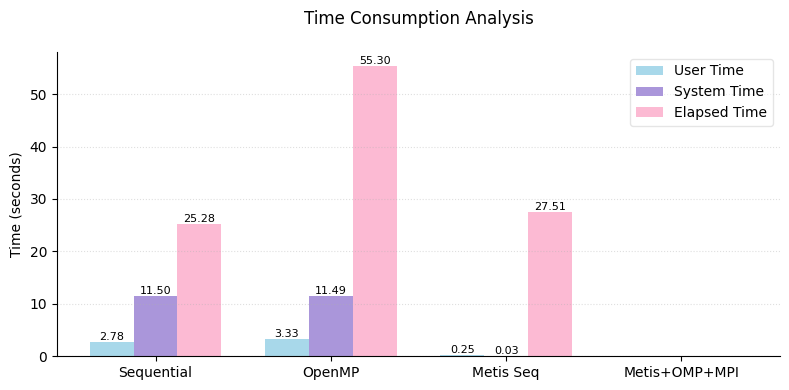

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Data
features = ['Sequential', 'OpenMP', 'Metis Seq', 'Metis+OMP+MPI']
user_time = [2.78, 3.33, 0.25, 0]
system_time = [11.50, 11.49, 0.03, 0]
elapsed_time = [25.28, 55.30, 27.51, 0]

# Colors
colors = ['#a8d8ea', '#aa96da', '#fcbad3']  # Pastel blue, purple, pink

# Plot setup
plt.figure(figsize=(8, 4))
bar_width = 0.25
index = np.arange(len(features))

bars1 = plt.bar(index, user_time, bar_width, label='User Time', color=colors[0])
bars2 = plt.bar(index + bar_width, system_time, bar_width, label='System Time', color=colors[1])
bars3 = plt.bar(index + 2*bar_width, elapsed_time, bar_width, label='Elapsed Time', color=colors[2])

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2, height,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=8)

# Styling
plt.title('Time Consumption Analysis', pad=20)
plt.ylabel('Time (seconds)')
plt.xticks(index + bar_width, features)
plt.legend(framealpha=0.5)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('time_consumption_compact.png', dpi=100)
plt.show()

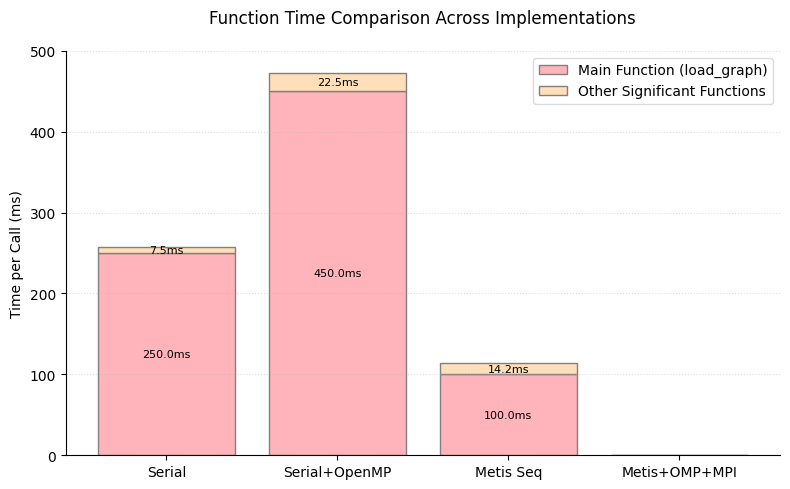

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data preparation
implementations = ['Serial', 'Serial+OpenMP', 'Metis Seq', 'Metis+OMP+MPI']
main_function = [250, 450, 100, 0]  # ms/call
other_functions = [
    [7.5, 22.5, 1.67+2.5+10, 0],  # Sum of other significant functions
    [0, 0, 0, 0]  # Placeholder for negligible functions
]

# Pastel color scheme
colors = ['#FFB3BA', '#FFDFBA', '#BAFFC9', '#BAE1FF']  # Red, orange, green, blue pastels

# Plot setup
plt.figure(figsize=(8, 5))

# Stacked bar plot
bottom = np.zeros(len(implementations))
bars_main = plt.bar(implementations, main_function, color=colors[0], 
                   label='Main Function (load_graph)', edgecolor='grey')
bottom += main_function

bars_other = plt.bar(implementations, other_functions[0], bottom=bottom, 
                    color=colors[1], label='Other Significant Functions', edgecolor='grey')
bottom += other_functions[0]

# Add value labels
for bars in [bars_main, bars_other]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Only label non-zero values
            y_pos = bar.get_y() + height/2
            plt.text(bar.get_x() + bar.get_width()/2, y_pos,
                    f'{height:.1f}ms', ha='center', va='center', fontsize=8)

# Styling
plt.title('Function Time Comparison Across Implementations', pad=20)
plt.ylabel('Time per Call (ms)')
plt.ylim(0, 500)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.grid(axis='y', linestyle=':', alpha=0.4)
plt.legend(loc='upper right', framealpha=0.7)

plt.tight_layout()
plt.savefig('function_time_comparison.png', dpi=120, bbox_inches='tight')
plt.show()